In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("sciPyPart2.ipynb")

## Lecture Section

In this lecture, we will cover more of the `scipy` library.

We will cover:
* Regression
* Correlation
    * Pearson's Correlation
    * Spearman's Correlation
* ANOVA

It is not possible to cover the entire library: the `stats` portion alone would take an entire class! If you want to explore functions and methods not covered here, visit this site:
https://docs.scipy.org/doc/scipy/reference/stats.html

### Regression

Let's use the `tips` dataset again!

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
tips = sns.load_dataset("tips")
tips = tips.dropna()

Linear regression with `scipy` is easy - we use the `stat.linregress` function. The first argument is our `x`, and the second is our `y` variable. It returns our slope and intercept of our regression line, the pearson correlation coefficient, the p-value (null hypothesis is that the slope == 0), and the standard error of the estimated slope (gradient).

In [5]:
x = tips["total_bill"]
y = np.log(tips["tip"])
# we log because the tips data is not perfectly linear
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

slope

np.float64(0.031912559981447215)

In [6]:
intercept

np.float64(0.37111761888560957)

In [7]:
r_value

np.float64(0.6513622387757699)

In [8]:
p_value

np.float64(7.578929570656348e-31)

In [9]:
std_err

np.float64(0.002389680117287643)

To plot, we can use what we learned from `seaborn`!

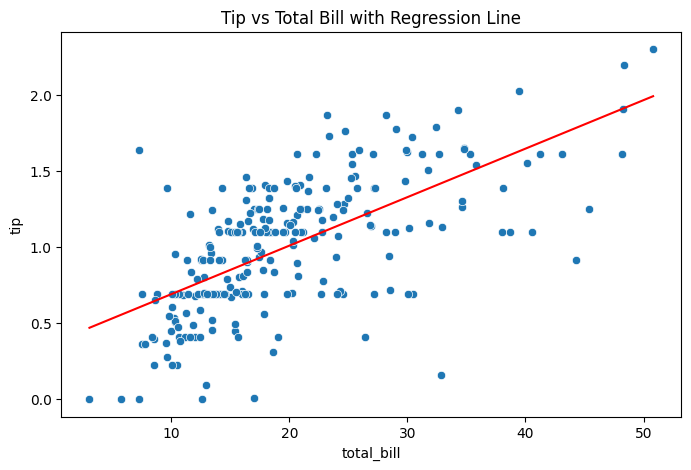

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x=x, y=y)
x_vals = np.linspace(x.min(), x.max(), 100)
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color='red')
plt.title("Tip vs Total Bill with Regression Line")
plt.show()

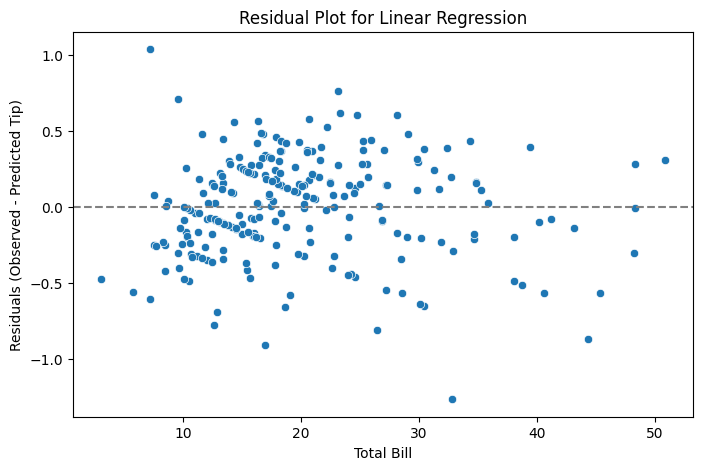

In [ ]:
y_pred = intercept + slope * x
residuals = y - y_pred

# Plot residuals
plt.figure(figsize=(8, 5))
sns.scatterplot(x=x, y=residuals)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Total Bill")
plt.ylabel("Residuals (Observed - Predicted Tip)")
plt.title("Residual Plot for Linear Regression")
plt.show()

**Why did I `log` the dependant variable? **

Great question! The raw data shows some heteroscedasticity - there is unequal variance of the residuals. To fix this, I transformed the dependant variable. The residual plot looks much less uniform this way, and our results are more trustworthy. You can remove the log and run the code again, if you want!

### Correlation

By doing linear regression in `scipy`, the Pearson's correlation coefficient and p-value is given to us. We might want them without using the `linregress()` function, though. Or maybe we want Spearman's coefficient. We can easily find these by using `stats.pearsonr()` or `stats.spearmanr()`.

Notice that the output of the Pearson's coefficient and p-value matches those returned above!

In [12]:
pearson_corr, pearson_p = stats.pearsonr(x, y)
spearman_corr, spearman_p = stats.spearmanr(x, y)

print("Pearson Correlation: ", pearson_corr)
print("Pearson P-Value: ", pearson_p)

print("Spearman Correlation: ", spearman_corr)
print("Spearman P-Value: ", spearman_p)

Pearson Correlation:  0.6513622387757703
Pearson P-Value:  7.578929570655531e-31
Spearman Correlation:  0.6789681219001009
Spearman P-Value:  2.5011584409235997e-34


### ANOVA

We can also run ANOVAs with `scipy`. For example, maybe we want to know if average tips change with the day of the week.

The first line uses list comprehension. It is the same as:

```
groups = []
for name, group in tips.groupby("day", observed=True):
    groups.append([group["tip"].values)
```

It uses `pandas` `groupby()` to group our dataset based on the categories of the `day` column, or the days of the week. The `for-loop` iterates over these groups: `name` is the day, and `group` holds the data. We only want the `tip` column values, so we extract it from each group, and `.append()` that data (for each group) into the `groups` list.

Now that we have the tip data for each day of the week, we can pass it to `stats.f_oneway()`. It takes groups of data - since our is in a list, we can use the `*` operator to automatically unpack those values.

All that's left is to print our results and plot, if we want to!


F-statistic:  1.6723551980998697
p-value:  0.1735885553040583


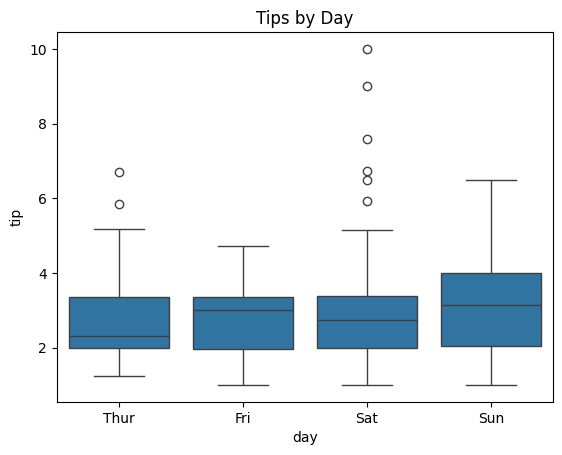

In [13]:
groups = [group["tip"].values for name, group in tips.groupby("day", observed=True)]
f_stat, p_val = stats.f_oneway(*groups)
print("F-statistic: ", f_stat)
print("p-value: ", p_val)

sns.boxplot(data=tips, x="day", y="tip")
plt.title("Tips by Day")
plt.show()

Looks like the average tips on different days don't change very much.

We will save two-way ANOVAs for the `statsmodels` (hypothesisTesting) lecture :)

## Assignment Section

**Question 1.**
Using the 'diamonds' dataset from seaborn, do linear regression between the 'carat' (x) and 'price' (y) variables in two ways. First, do it without '.log' on the y variable, then do it with. Pay attention to the error. Return the slope, intercept, r_value, p_value, and std_err for both runs.

In [ ]:
diamonds = sns.load_dataset("diamonds")
x = diamonds["carat"]
y = diamonds["price"]
y_log = np.log(y)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
slope_log, intercept_log, r_value_log, p_value_log, std_err_log = stats.linregress(x, y_log)


In [19]:
grader.check("q1")

q1 results: All test cases passed!

**Question 2.** Plot the residuals for the non-logged version, and the logged version. Does the variance seem more constant for one vs. the other? Copy your residuals of the model with the most constant variance to the 'solution' variable.

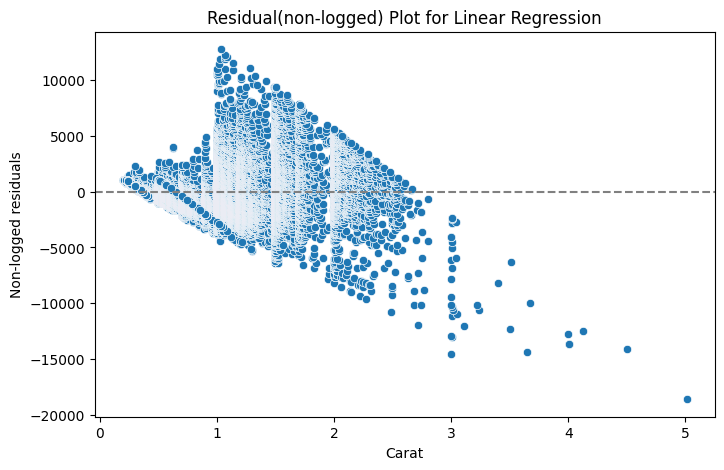

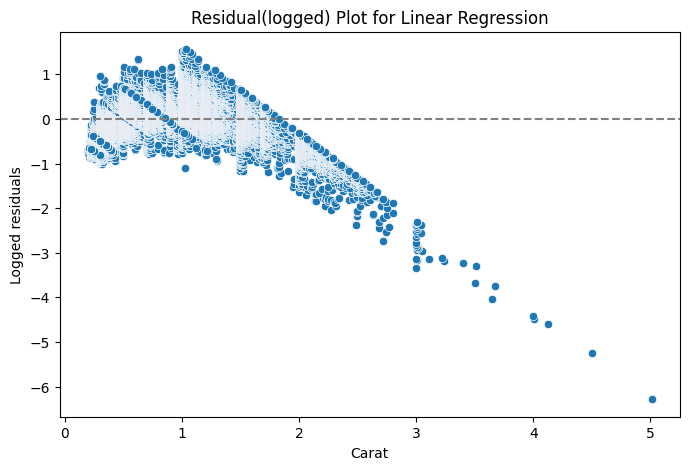

In [24]:
y_pred = intercept + slope * x
residuals = y - y_pred

# Plot residuals
plt.figure(figsize=(8, 5))
sns.scatterplot(x=x, y=residuals)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Carat")
plt.ylabel("Non-logged residuals")
plt.title("Residual(non-logged) Plot for Linear Regression")
plt.show()

y_pred_log = intercept_log + slope_log * x
residuals_log = y_log - y_pred_log

# Plot residuals
plt.figure(figsize=(8, 5))
sns.scatterplot(x=x, y=residuals_log)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Carat")
plt.ylabel("Logged residuals")
plt.title("Residual(logged) Plot for Linear Regression")
plt.show()

solution = residuals_log

In [25]:
grader.check("q2")

q2 results: All test cases passed!

**Question 3.** Run an ANOVA on the 'penguins' dataset from seaborn. You want to compare the average 'body_mass_g' for each penguin 'species'.

F-statistic: 341.8948949481461
p-value: 3.74450512630046e-81


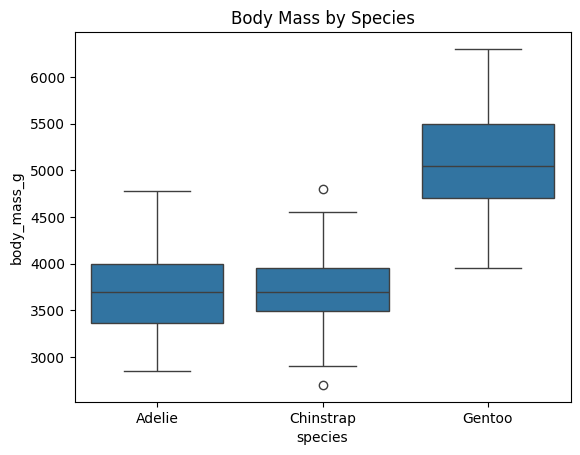

In [27]:
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins").dropna()
groups = [group["body_mass_g"].values for name, group in penguins.groupby("species", observed=True)]

f_stat, p_val = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_val)

sns.boxplot(data=penguins, x="species", y="body_mass_g")
plt.title("Body Mass by Species")
plt.show()

In [28]:
grader.check("q3")

q3 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [29]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!